In [10]:
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
segments = pd.read_csv("../data/processed/customer_segments.csv")
elbow = pd.read_csv("../data/processed/kmeans_elbow_scores.csv")
summary = pd.read_csv("../data/processed/kmeans_cluster_summary.csv")

segments.head()

,CustomerID,recency,frequency,monetary,recency_score,frequency_score,monetary_score,rfm_score,segment,cluster
0,14646,2,73,280206.02,5,5,5,555,Champions,2
1,18102,1,60,259657.30,5,5,5,555,Champions,2
2,17450,8,46,194550.79,5,5,5,555,Champions,2
3,14911,1,201,143825.06,5,5,5,555,Champions,2
4,14156,10,55,117379.63,5,5,5,555,Champions,2


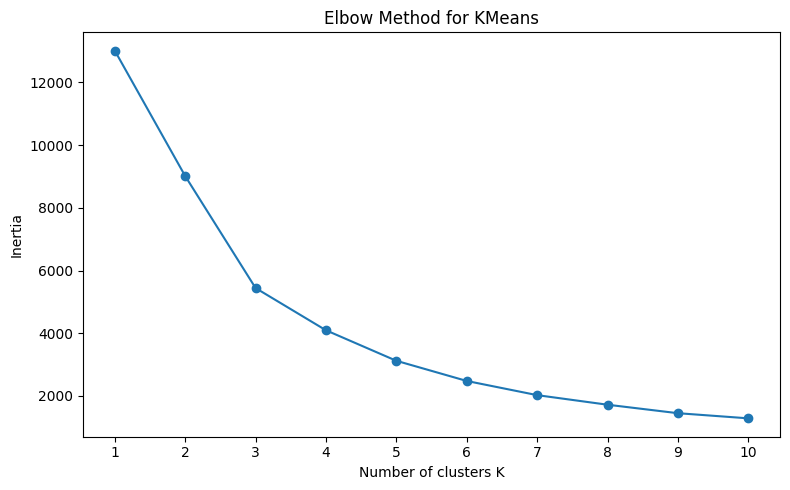

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(elbow["k"], elbow["inertia"], marker="o")
plt.title("Elbow Method for KMeans")
plt.xlabel("Number of clusters K")
plt.ylabel("Inertia")
plt.xticks(elbow["k"])
plt.tight_layout()
plt.show()

In [13]:
summary

,cluster,customer_count,avg_recency,avg_frequency,avg_monetary
0,2,13,7.384615,82.538462,127338.313846
1,0,211,15.672986,22.047393,12453.225924
2,3,3052,43.920380,3.656291,1350.140532
3,1,1062,248.564030,1.551789,478.107581


## Business Interpretation

The KMeans segmentation highlights four customer groups with very different business value.

### Cluster 2 - VIP / Champions

This is a very small group of 13 customers, but they have the strongest performance:
- very low average recency;
- very high average frequency;
- very high average monetary value.

These customers purchased recently, order very often and generate very high revenue.

Recommended action: protect this group with VIP benefits, personalized offers, priority service and exclusive campaigns.

### Cluster 0 - High Value Loyal Customers

This group contains 211 customers with strong value:
- low average recency;
- high average frequency;
- high average monetary value.

These customers are loyal and valuable, but less extreme than the VIP group.

Recommended action: increase loyalty, encourage repeat purchases and move them toward VIP status.

### Cluster 3 - Regular / Potential Customers

This is the largest group with 3052 customers:
- moderate average recency;
- moderate frequency;
- moderate monetary value.

This group represents the core customer base. Because it contains many customers, small improvements in purchase frequency or basket size can have a large business impact.

Recommended action: use cross-sell campaigns, product recommendations, bundles and targeted promotions.

### Cluster 1 - Dormant / Low Engagement Customers

This group contains 1062 customers:
- high average recency;
- low frequency;
- low monetary value.

These customers have not purchased recently and generate limited value.

Recommended action: use low-cost reactivation campaigns, win-back emails and limited-time offers, while controlling marketing spend.

## Strategic Priority

The recommended marketing priority is:
1. protect VIP customers;
2. grow high-value loyal customers;
3. develop regular customers at scale;
4. reactivate dormant customers carefully.

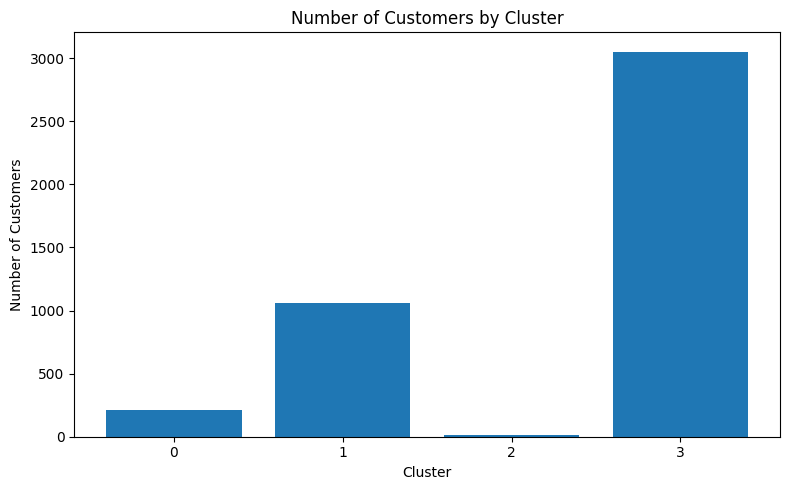

In [14]:
cluster_counts = segments["cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)
plt.title("Number of Customers by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

## Interpretation

KMeans regroupe automatiquement les clients selon leurs comportements RFM.

Les variables utilisées sont :
- `recency`
- `frequency`
- `monetary`

Le graphique du coude aide à choisir un nombre de clusters raisonnable.

Le résumé des clusters permet d'interpréter chaque groupe selon :
- le nombre de clients ;
- la récence moyenne ;
- la fréquence moyenne ;
- le montant moyen dépensé.

Les clusters peuvent ensuite être traduits en segments business comme VIP, réguliers, potentiels ou dormants.